In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("D:\\FDS project\\dataset\\weather.csv")
df.head()

,city,lat,lon,temperature,weather_code,sunrise,sunset,moonrise,moonset,co,...,pm10,wind_speed,wind_degree,wind_dir,pressure,humidity,cloudcover,feelslike,uv_index,visibility
0,New Delhi,28.600,77.200,21,143,7:05 AM,5:26 PM,1:04 AM,1:06 PM,1411.85,...,140.05,4,34,NE,1017,53,50,21,0,1
1,Mumbai,18.975,72.826,30,122,7:03 AM,6:03 PM,1:20 AM,1:29 PM,644.85,...,47.05,18,300,WNW,1011,35,0,32,0,4
2,Kolkata,22.570,88.370,21,143,6:07 AM,4:54 PM,12:16 AM,12:23 PM,457.85,...,47.25,8,3,N,1014,73,0,21,0,3
3,Chennai,13.083,80.283,26,143,6:22 AM,5:44 PM,12:48 AM,1:00 PM,275.85,...,35.15,19,31,NNE,1012,65,25,28,0,5
4,Bengaluru,12.983,77.583,24,113,6:32 AM,5:55 PM,12:59 AM,1:11 PM,243.85,...,26.35,9,76,ENE,1015,25,0,24,0,10


In [7]:
df.isnull().sum()

,0
city,0
lat,0
lon,0
temperature,0
weather_code,0
sunrise,0
sunset,0
moonrise,0
moonset,0
co,0


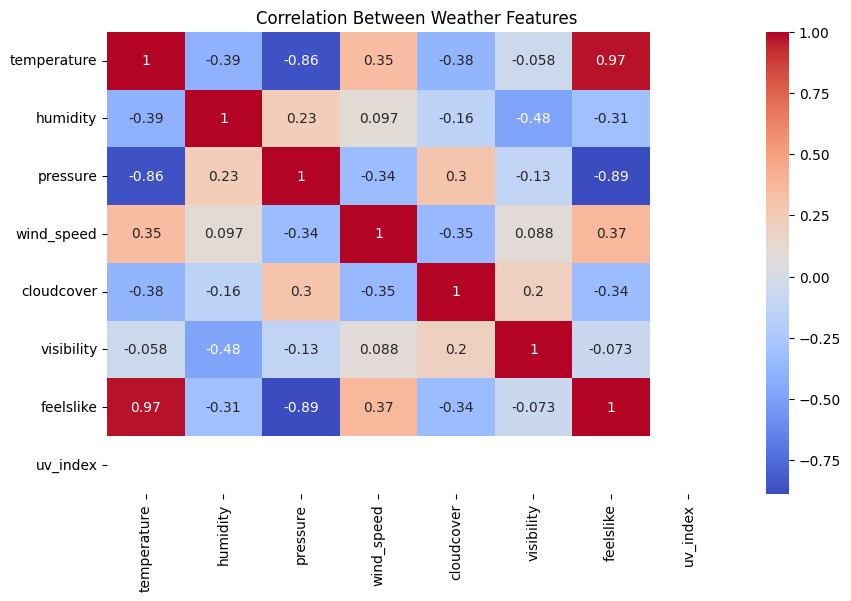

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['temperature','humidity','pressure','wind_speed','cloudcover','visibility','feelslike','uv_index']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Between Weather Features")
plt.show()

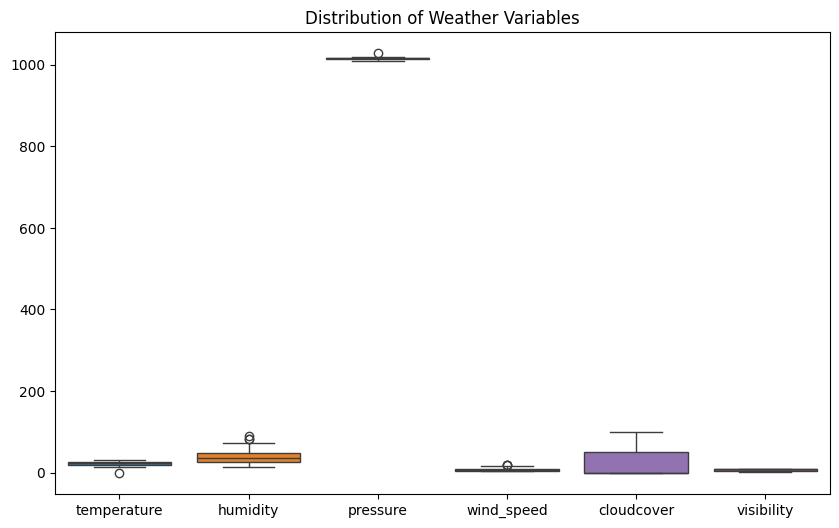

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['temperature','humidity','pressure','wind_speed','cloudcover','visibility']])
plt.title("Distribution of Weather Variables")
plt.show()

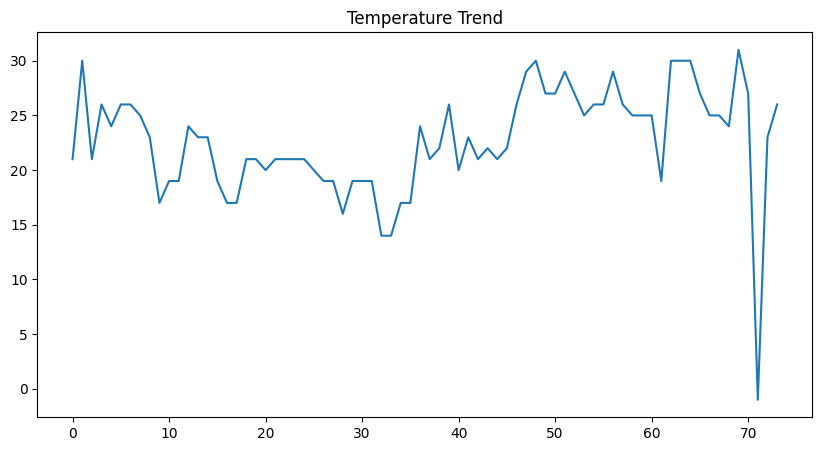

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['temperature'])
plt.title("Temperature Trend")
plt.show()

In [11]:
features = df[['temperature','humidity','pressure','wind_speed','cloudcover','visibility','feelslike','uv_index']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [12]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(scaled_data)

In [13]:
df['anomaly'].value_counts() #1 normal weather, -1 abnormal weather


,count
anomaly,
1,70
-1,4


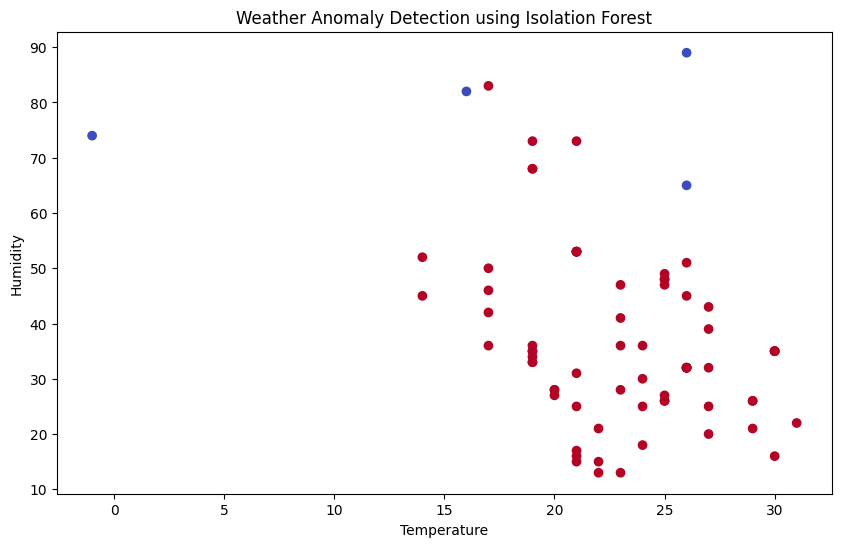

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(df['temperature'], df['humidity'],
            c=df['anomaly'],
            cmap='coolwarm')

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Weather Anomaly Detection using Isolation Forest")
plt.show()

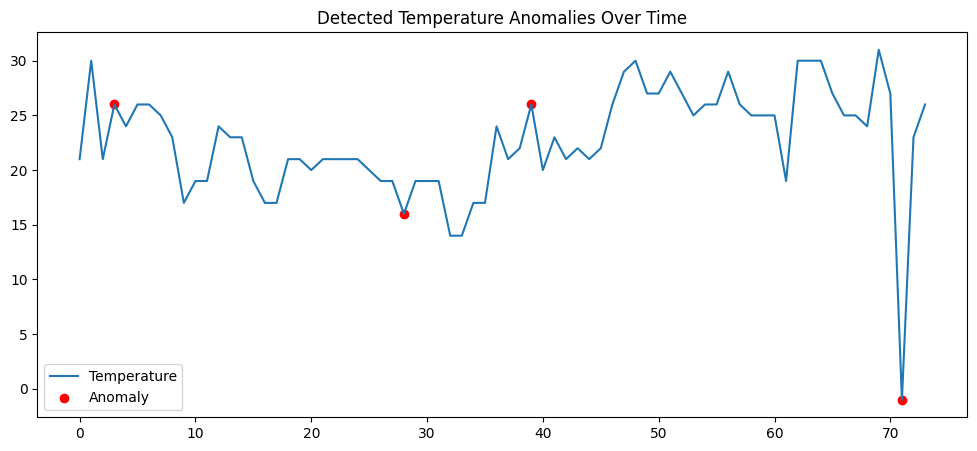

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df['temperature'], label="Temperature")

anomalies = df[df['anomaly'] == -1]

plt.scatter(anomalies.index,
            anomalies['temperature'],
            color='red',
            label='Anomaly')

plt.legend()
plt.title("Detected Temperature Anomalies Over Time")
plt.show()

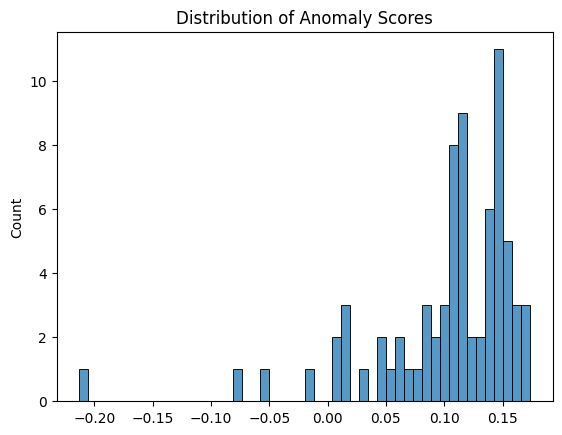

In [16]:
scores = model.decision_function(scaled_data)

sns.histplot(scores, bins=50)
plt.title("Distribution of Anomaly Scores")
plt.show()

In [17]:
df.groupby("anomaly")[['temperature','humidity','pressure','wind_speed','cloudcover','visibility']].mean()

,temperature,humidity,pressure,wind_speed,cloudcover,visibility
anomaly,,,,,,
-1,16.750000,77.500000,1016.500000,12.250000,27.250000,6.500000
1,23.028571,36.485714,1014.485714,7.014286,24.128571,7.485714
